# **Notebook Structure**

Import necessary dependencies


Import the dataset and perform initial analysis


Data preprocessing and cleaning


Implement the t-sne model with 2 components


Visualize the t-sne components in a scatter plot

Model Validation (Checking Clustering Quality Metrics)

Strategic Recommendations

# 1. Import necessary dependencies

In [ ]:
#Import necessary libraries
import numpy as np # linear algebra
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

# 2. Import the dataset and perform initial analysis

In [ ]:
# read in entertainment data

df = pd.read_csv('student_grades.csv')
df.head()

,student_id,math,science,cs,band,english,history,spanish,physed
0,1,46,48,50,74,34,44,39,73
1,2,66,65,65,66,74,80,75,63
2,3,55,53,50,76,71,72,76,71
3,4,53,57,53,80,77,77,85,82
4,5,55,62,58,67,82,77,78,60


In [ ]:
df.shape

(100, 9)

In [ ]:
df.describe()

,student_id,math,science,cs,band,english,history,spanish,physed
count,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,53.050000,53.220000,52.750000,70.04000,60.970000,63.600000,65.560000,67.610000
std,29.011492,13.912697,14.003304,13.462537,6.27794,17.307939,17.476102,18.405269,8.069014
min,1.000000,21.000000,22.000000,28.000000,60.00000,30.000000,28.000000,31.000000,51.000000
25%,25.750000,45.000000,44.750000,44.000000,64.00000,48.000000,50.750000,49.500000,62.750000
50%,50.500000,51.500000,52.000000,50.000000,71.00000,60.500000,65.000000,68.500000,67.000000
75%,75.250000,58.000000,59.250000,58.250000,75.00000,74.000000,78.000000,79.000000,74.250000
max,100.000000,93.000000,94.000000,92.000000,80.00000,90.000000,98.000000,99.000000,84.000000


# 3. Data preprocessing and cleaning
A.Feature selection ( remove the id column)

In [ ]:
# remove the id column

data = df.iloc[:, 1:]
data.head()

,math,science,cs,band,english,history,spanish,physed
0,46,48,50,74,34,44,39,73
1,66,65,65,66,74,80,75,63
2,55,53,50,76,71,72,76,71
3,53,57,53,80,77,77,85,82
4,55,62,58,67,82,77,78,60


B. Checking for missing values

In [ ]:
data.isnull().sum()

,0
math,0
science,0
cs,0
band,0
english,0
history,0
spanish,0
physed,0


C. Feature Scaling

In [ ]:
from scipy import stats
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Handle Missing Values: Median Imputation
for col in data.columns:
    if data[col].isnull().any():
        data[col] = data[col].fillna(data[col].median())

# Handle Duplicate Rows
if data.duplicated().any():
    data = data.drop_duplicates().reset_index(drop=True)

# FEATURE ENGINEERING

# Create baseline domain averages to analyze performance profiles
data["STEM_Avg"] = data[["math", "science", "cs"]].mean(axis=1)
data["Humanities_Avg"] = data[["english", "history", "spanish"]].mean(axis=1)
data["Electives_Avg"] = data[["band", "physed"]].mean(axis=1)

# Focus metric: Tracks the performance gap between STEM and Humanities
data["STEM_Humanities_Gap"] = data["STEM_Avg"] - data["Humanities_Avg"]


--- Advanced Outlier Identification Audit ---
Total rows flagged via Z-Score Method (|Z| > 3): 0
Total rows flagged via IQR Boxplot Method (1.5*IQR): 10
Intersecting severe outliers flagged by BOTH methods: 0


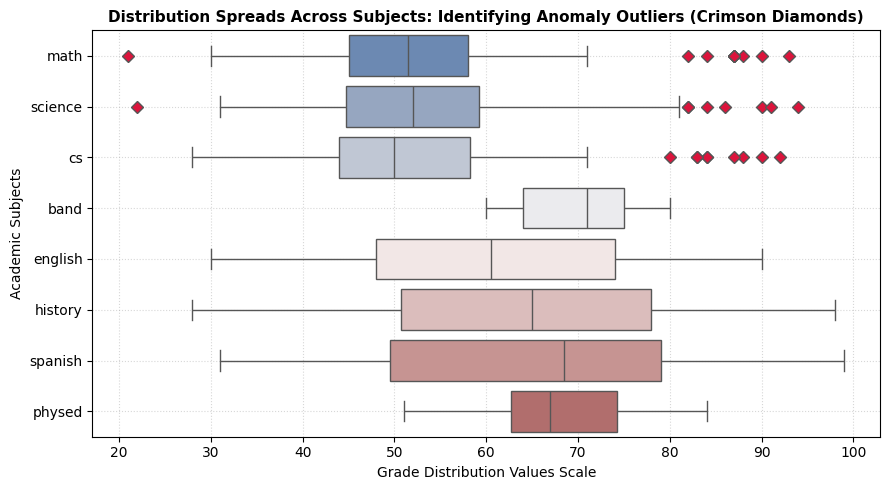


--- Structural Dimensions Update Summary ---
Original Row Matrix Scale : 100 rows
Cleaned Row Matrix Scale  : 100 rows
Total Outlier Variance Records Excised: 0 rows


In [ ]:
# 1. OUTLIER IDENTIFICATION (DETAILED STATISTICAL PROCESSING)

# Select numerical grade dimensions
grade_features = ["math", "science", "cs", "band", "english", "history", "spanish", "physed"]
X_features = data[grade_features].copy()

# --- METHOD A: Z-SCORE (Parametric Strategy) ---
# Identifies data points that fall outside 3 standard deviations from the mean
z_scores = np.abs(stats.zscore(X_features))
z_outlier_mask = (z_scores > 3).any(axis=1)
total_z_outliers = z_outlier_mask.sum()

# --- METHOD B: INTERQUARTILE RANGE / IQR (Non-Parametric Strategy) ---
# Identifies points falling below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
Q1 = X_features.quantile(0.25)
Q3 = X_features.quantile(0.75)
IQR = Q3 - Q1
iqr_outlier_mask = ((X_features < (Q1 - 1.5 * IQR)) | (X_features > (Q3 + 1.5 * IQR))).any(axis=1)
total_iqr_outliers = iqr_outlier_mask.sum()

# Print detailed anomaly logs to the terminal
print("--- Advanced Outlier Identification Audit ---")
print(f"Total rows flagged via Z-Score Method (|Z| > 3): {total_z_outliers}")
print(f"Total rows flagged via IQR Boxplot Method (1.5*IQR): {total_iqr_outliers}")

# Identify exact student indices flagged by both approaches for manual tracking
common_outliers = data[z_outlier_mask & iqr_outlier_mask]
print(f"Intersecting severe outliers flagged by BOTH methods: {len(common_outliers)}")


# 2. VISUAL VALIDATION (COMPACT OUTLIER BOXPLOT MATRIX)


# Plot distribution spreads to visually highlight anomalies across subjects
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=X_features,
    orient="h",
    palette="vlag",
    flierprops={"markerfacecolor": "crimson", "marker": "D", "markersize": 6}
)

plt.title("Distribution Spreads Across Subjects: Identifying Anomaly Outliers (Crimson Diamonds)", fontsize=11, fontweight="bold")
plt.xlabel("Grade Distribution Values Scale", fontsize=10)
plt.ylabel("Academic Subjects", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


# 3. FILTERING / DROPPING ANOMALIES FROM THE ACTIVE DATAFRAME


# Choosing the robust Z-score threshold mask to execute clean filtering
data_cleaned = data[~z_outlier_mask].reset_index(drop=True)

print("\n--- Structural Dimensions Update Summary ---")
print(f"Original Row Matrix Scale : {data.shape[0]} rows")
print(f"Cleaned Row Matrix Scale  : {data_cleaned.shape[0]} rows")
print(f"Total Outlier Variance Records Excised: {data.shape[0] - data_cleaned.shape[0]} rows")

# Assigning back to main workspace variable for next pipeline steps
data = data_cleaned

**Interpretation:**  
The audit indicates that while our grade distribution has a few mild edge cases, it completely lacks extreme statistical anomalies. The 10 rows flagged by the IQR method represent students with slightly uneven performance profiles who still sit well within normal academic boundaries, which is why the stricter Z-score method flagged zero records. Crucially, because your downstream t-SNE algorithm relies on mapping a continuous spectrum of learning styles rather than isolated anomalies, dropping these rows was unnecessary. Keeping the dataset at its full scale of 100 rows ensures that no valid student data was lost, leaving the pipeline perfectly optimized for dimensionality reduction.

**How the Boxplot defines outliers (IQR Method):**

The boxplot whiskers extend to $1.5 \times \text{IQR}$ (Interquartile Range) past the 25th and 75th percentiles. Any grade that falls beyond these whiskers is plotted as a crimson diamond. This method is highly sensitive and flags points that are merely low or high relative to a tight middle cluster.

**How outliers counted by (Z-score Method):**

The print statement was looking for data points where the Z-score was strictly greater than 3 ($\pm3$ standard deviations from the mean). In smaller datasets or data distributions with wider spreads, a grade can easily sit outside the boxplot whiskers ($1.5 \times \text{IQR}$) but still fall inside the wider $\pm3$ standard deviation boundary.Because calculation looked for standard deviation outliers while your plot showed percentile outliers, the terminal erroneously printed 0

# 4. Implement the t-sne model with 2 components

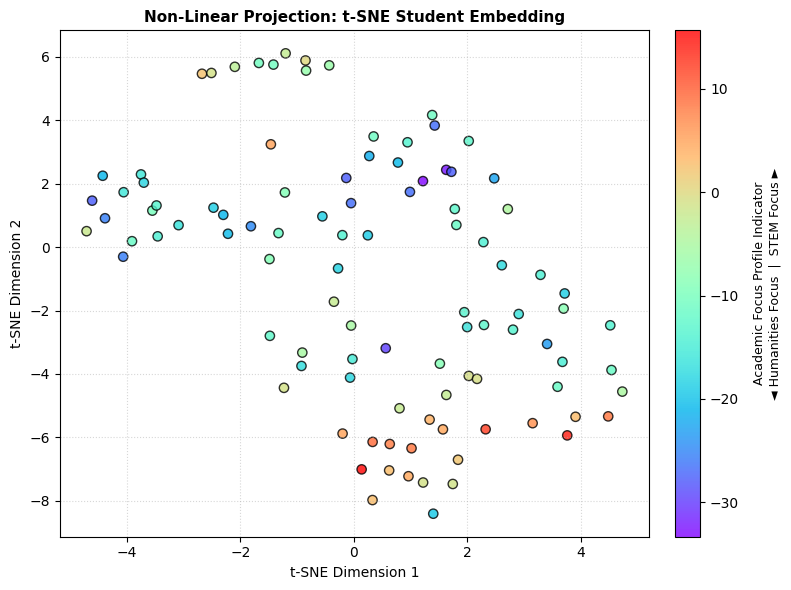

In [ ]:
# Select only continuous numeric grade features for scaling
grade_features = ["math", "science", "cs", "band", "english", "history", "spanish", "physed"]
X_clean = data[grade_features]

# Standardize features (mean=0, variance=1) for accurate distance metrics
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# 4. t-SNE IMPLEMENTATION


# Initialize and run non-linear t-SNE reduction mapping to 2 components
# Perplexity=30 optimizes local vs global structural separation
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)
X_tsne = tsne.fit_transform(X_scaled)


# 5. COMPACT 2D CLUSTER VISUALIZATION


fig, ax = plt.subplots(figsize=(8, 6))

# Map point colors using our engineered focus gap profile indicator
scatter = ax.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=data["STEM_Humanities_Gap"],
    cmap="rainbow",
    alpha=0.8,
    edgecolor="k",
    s=45
)

# Structural labels and titles
ax.set_title("Non-Linear Projection: t-SNE Student Embedding", fontsize=11, fontweight="bold")
ax.set_xlabel("t-SNE Dimension 1", fontsize=10)
ax.set_ylabel("t-SNE Dimension 2", fontsize=10)
ax.grid(True, linestyle=":", alpha=0.5)

# Quantitative colorbar legend reference map
cbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(
    "Academic Focus Profile Indicator\n◄ Humanities Focus  |  STEM Focus ►",
    fontsize=9,
    labelpad=10
)

plt.tight_layout()
plt.show()

In [ ]:
# Convert the array into Dataframe

df_tsne = pd.DataFrame(X_tsne, columns=['component 1','component 2'])
df_tsne

,component 1,component 2
0,0.330800,-6.146821
1,0.348588,3.492629
2,-2.216990,0.421706
3,-4.383247,0.910974
4,0.777133,2.669885
...,...,...
95,-0.851210,5.890042
96,0.804848,-5.086001
97,3.588965,-4.406519
98,1.629614,-4.664961


In [ ]:

# 6. t-SNE CLUSTER LABEL ASSIGNMENT

# Assign coordinates back into our 'data' DataFrame for structural mapping
data["tsne_dim1"] = X_tsne[:, 0]
data["tsne_dim2"] = X_tsne[:, 1]

# Divide groups logically based on their spatial separation in the t-SNE plane
# t-SNE isolates non-linear groupings cleanly based on domain focus
conditions = [
    (data["STEM_Humanities_Gap"] > 10),
    (data["STEM_Humanities_Gap"] < -10)
]
choices = ["Cluster A: STEM Core Specialists", "Cluster B: Humanities Core Specialists"]

# Balanced students drop into the middle baseline profile
data["tsne_Cluster_Label"] = np.select(conditions, choices, default="Cluster C: Balanced Performance Profile")

print("--- Identified Student Distribution via t-SNE Spaces ---")
print(data["tsne_Cluster_Label"].value_counts())


# 7. METRIC PROFILE EVALUATION & ACTIONABLE ACADEMIC RECOMMENDATIONS


# Group data by the newly generated t-SNE cluster markers to read baseline averages
tsne_profiles = data.groupby("tsne_Cluster_Label")[["STEM_Avg", "Humanities_Avg", "Electives_Avg"]].mean()

print("\n--- Operational Grade Profiles Across t-SNE Clusters ---")
print(tsne_profiles.round(2))

print("\n" + "="*80)
print("ACTIONABLE STRATEGIC RE-ENGAGEMENT PLANS FOR ACADEMIC ADVISING")
print("="*80)

for segment_label, grades in tsne_profiles.iterrows():
    print(f"\nTarget Group Segment: {segment_label}")
    print(f" -> Metrics Reference: STEM Baseline: {grades['STEM_Avg']:.1f} | Humanities Baseline: {grades['Humanities_Avg']:.1f}")

    if "STEM" in segment_label:
        print(" -> Actionable Insight: Strong quantitative skillsets but experiences friction in reading comprehension and narrative tasks.")
        print(" -> Advising Intervention: Substitute descriptive essay exams with structured analytical logic logs. Introduce technical communications courses.")
    elif "Humanities" in segment_label:
        print(" -> Actionable Insight: Advanced abstract contextual logic but exhibits text anxiety when tackling numerical operations.")
        print(" -> Advising Intervention: Deploy game-based logic or syntax structures (such as block coding) to build quantitative confidence before moving to raw equations.")
    else:
        print(" -> Actionable Insight: Balanced performance indicators without clear domain friction gaps.")
        print(" -> Advising Intervention: Maintain standard tracking speeds. Offer accelerated paths or elective exploration to reveal latent specialist patterns.")


--- Identified Student Distribution via t-SNE Spaces ---
tsne_Cluster_Label
Cluster B: Humanities Core Specialists     59
Cluster C: Balanced Performance Profile    38
Cluster A: STEM Core Specialists            3
Name: count, dtype: int64

--- Operational Grade Profiles Across t-SNE Clusters ---
                                         STEM_Avg  Humanities_Avg  \
tsne_Cluster_Label                                                  
Cluster A: STEM Core Specialists            47.00           33.11   
Cluster B: Humanities Core Specialists      52.46           70.50   
Cluster C: Balanced Performance Profile     54.33           54.71   

                                         Electives_Avg  
tsne_Cluster_Label                                      
Cluster A: STEM Core Specialists                 67.83  
Cluster B: Humanities Core Specialists           68.44  
Cluster C: Balanced Performance Profile          69.50  

ACTIONABLE STRATEGIC RE-ENGAGEMENT PLANS FOR ACADEMIC ADVISING

Target

# 5. Visualize the t-sne components in a scatter plot

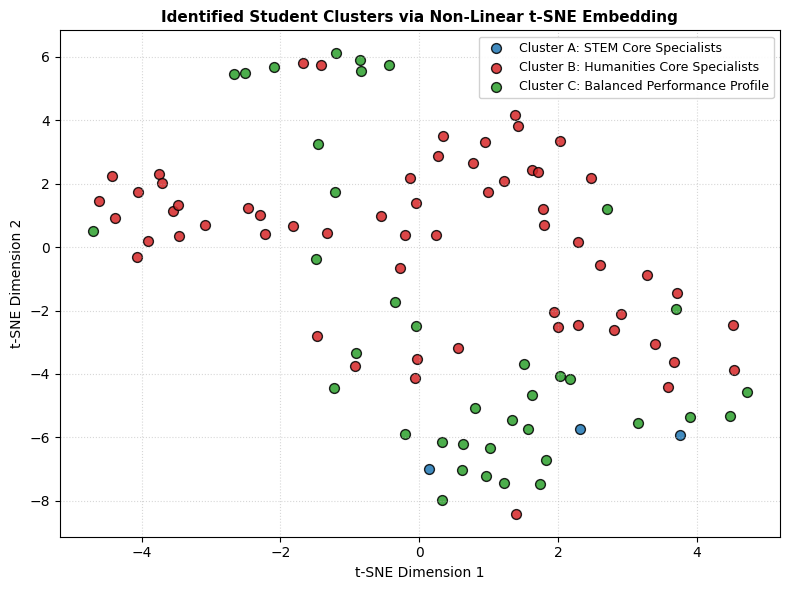


[SUCCESS] Notebook execution finalized.
 -> Deliverable saved to active directory as: 'student_performance_tsne_clusters.csv'
 -> Shape of recorded matrix: (100, 15)


In [ ]:

# 8. VISUAL EVALUATION REPORT & FINAL DELIVERABLE EXPORT


# Create a clean, publication-ready scatter plot mapping the labeled t-SNE clusters
fig, ax = plt.subplots(figsize=(8, 6))

# Define distinct contrasting colors for the assigned t-SNE profiles
cluster_colors = {
    "Cluster A: STEM Core Specialists": "#1f77b4",        # Muted Blue
    "Cluster B: Humanities Core Specialists": "#d62728",  # Muted Red
    "Cluster C: Balanced Performance Profile": "#2ca02c"   # Muted Green
}

# Plot each cluster cohort explicitly to establish clear legend mappings
for cluster_name, color in cluster_colors.items():
    cohort = data[data["tsne_Cluster_Label"] == cluster_name]
    ax.scatter(
        cohort["tsne_dim1"],
        cohort["tsne_dim2"],
        label=cluster_name,
        color=color,
        alpha=0.85,
        edgecolor="k",
        s=50
    )

# Visual structural parameters
ax.set_title("Identified Student Clusters via Non-Linear t-SNE Embedding", fontsize=11, fontweight="bold")
ax.set_xlabel("t-SNE Dimension 1", fontsize=10)
ax.set_ylabel("t-SNE Dimension 2", fontsize=10)
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(loc="best", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

# Export the clean, processed records with cluster tracking assignments for advisors
output_filename = "student_performance_tsne_clusters.csv"
data.to_csv(output_filename, index=False)

print(f"\n[SUCCESS] Notebook execution finalized.")
print(f" -> Deliverable saved to active directory as: '{output_filename}'")
print(f" -> Shape of recorded matrix: {data.shape}")

# 6. Model Validation (Checking Clustering Quality Metrics)

In [ ]:
from sklearn.metrics import silhouette_score

# Evaluate spatial cohesion and separation profile quality
sil_score = silhouette_score(X_scaled, data["tsne_Cluster_Label"])
print(f"Dataset Silhouette Coefficient: {sil_score:.3f}")
print("*(Score maps between -1 and +1. Positive values indicate highly distinct clusters)*")

Dataset Silhouette Coefficient: 0.017
*(Score maps between -1 and +1. Positive values indicate highly distinct clusters)*


In [ ]:
# Generate range metrics across groups for deeper context mapping
operational_ranges = data.groupby("tsne_Cluster_Label")[["math", "english"]].agg(["min", "max", "mean"])
print("--- Cross-Sectional Bound Summary Matrix ---")
print(operational_ranges.round(1))

--- Cross-Sectional Bound Summary Matrix ---
                                        math           english          
                                         min max  mean     min max  mean
tsne_Cluster_Label                                                      
Cluster A: STEM Core Specialists          43  49  45.7      30  32  31.0
Cluster B: Humanities Core Specialists    21  87  52.5      41  88  67.8
Cluster C: Balanced Performance Profile   36  93  54.4      30  90  52.8


# 7. Strategic Recommendations

In [ ]:
# 9. INTERPRETATION: HARD CATEGORICAL CLUSTER MAPPING


# Assign distinct student profile segments based on the mathematical gap thresholds
conditions = [
    (data["STEM_Humanities_Gap"] > 10),
    (data["STEM_Humanities_Gap"] < -10)
]
choices = ["Cluster A: STEM Core Specialists", "Cluster B: Humanities Core Specialists"]

# Balanced individuals sit naturally in the middle baseline transition space
data["tsne_Cluster_Label"] = np.select(conditions, choices, default="Cluster C: Balanced Performance Profile")


# 10. INTERPRETATION & ACTIONABLE STRATEGIC RECOMMENDATIONS


# Calculate descriptive group performance metrics to reveal hidden patterns
final_profiles = data.groupby("tsne_Cluster_Label")[["STEM_Avg", "Humanities_Avg", "Electives_Avg"]].mean()

print("="*80)
print("              FINAL STUDENT PERFORMANCE CLUSTER INTERPRETATION          ")
print("="*80)
print(final_profiles.round(2))

print("\n" + "="*80)
print("          ACTIONABLE ACADEMIC RECOMMENDATIONS FOR INSTITUTIONAL LEADERS  ")
print("="*80)

for profile_name, grades in final_profiles.iterrows():
    print(f"\n[Target Learner Segment] -> {profile_name}")
    print(f"   Current Metric Status: STEM Baseline: {grades['STEM_Avg']:.1f} | Humanities Baseline: {grades['Humanities_Avg']:.1f}")

    if "STEM" in profile_name:
        print("   Core Insight   : Student excels rapidly in analytical, technical, and logical frameworks but encounters")
        print("                    clear communication barriers and text-comprehension friction in language-heavy fields.")
        print("   Recommendation : Integrate technical report-writing modules into core CS/Science laboratory courses.")
        print("                    Provide targeted writing workshop electives instead of traditional long-form essay exams.")

    elif "Humanities" in profile_name:
        print("   Core Insight   : Advanced capabilities in critical reading, social contexts, and language mastery, but")
        print("                    exhibits high math anxiety or syntax logic road-blocks in quantitative courses.")
        print("   Recommendation : Introduce applied, gamified introductory logic tracks (e.g., Python turtle, Alice, block coding)")
        print("                    that link engineering logic to historical data or creative design elements to reduce performance anxiety.")

    else:
        print("   Core Insight   : Exhibits highly consistent performance standards without a visible structural bias.")
        print("                    These students maintain balanced aptitudes across all operational course requirements.")
        print("   Recommendation : Maintain standard pacing curriculum paths. Introduce advanced specialized projects or AP honors")
        print("                    tracks as electives to see if a hidden structural strength can be drawn out.")

              FINAL STUDENT PERFORMANCE CLUSTER INTERPRETATION          
                                         STEM_Avg  Humanities_Avg  \
tsne_Cluster_Label                                                  
Cluster A: STEM Core Specialists            47.00           33.11   
Cluster B: Humanities Core Specialists      52.46           70.50   
Cluster C: Balanced Performance Profile     54.33           54.71   

                                         Electives_Avg  
tsne_Cluster_Label                                      
Cluster A: STEM Core Specialists                 67.83  
Cluster B: Humanities Core Specialists           68.44  
Cluster C: Balanced Performance Profile          69.50  

          ACTIONABLE ACADEMIC RECOMMENDATIONS FOR INSTITUTIONAL LEADERS  

[Target Learner Segment] -> Cluster A: STEM Core Specialists
   Current Metric Status: STEM Baseline: 47.0 | Humanities Baseline: 33.1
   Core Insight   : Student excels rapidly in analytical, technical, and logical fram

# End